In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import xgboost as xgb
import optuna
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, log_loss, brier_score_loss,
                             confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import plot_importance

In [3]:
url = r"C:\Users\andre\Downloads\porto-seguro-safe-driver-prediction\sample_submission.csv"
taxi_drivers = pd.read_csv(url)

In [4]:
train_data = pd.read_csv(r"C:\Users\andre\Downloads\porto-seguro-safe-driver-prediction\train.csv")
test_data = pd.read_csv(r"C:\Users\andre\Downloads\porto-seguro-safe-driver-prediction\test.csv")

In [81]:
train_data

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,...,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,...,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,...,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,...,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,...,3,1,1,3,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595207,1488013,0,3,1,10,0,0,0,0,0,...,4,1,9,6,0,1,1,0,1,1
595208,1488016,0,5,1,3,0,0,0,0,0,...,4,1,3,8,1,0,1,0,1,1
595209,1488017,0,1,1,10,0,0,1,0,0,...,3,2,2,6,0,0,1,0,0,0
595210,1488021,0,5,2,3,1,0,0,0,1,...,4,1,4,2,0,1,1,1,0,0


In [6]:
train_data.nunique()

id                595212
target                 2
ps_ind_01              8
ps_ind_02_cat          5
ps_ind_03             12
ps_ind_04_cat          3
ps_ind_05_cat          8
ps_ind_06_bin          2
ps_ind_07_bin          2
ps_ind_08_bin          2
ps_ind_09_bin          2
ps_ind_10_bin          2
ps_ind_11_bin          2
ps_ind_12_bin          2
ps_ind_13_bin          2
ps_ind_14              5
ps_ind_15             14
ps_ind_16_bin          2
ps_ind_17_bin          2
ps_ind_18_bin          2
ps_reg_01             10
ps_reg_02             19
ps_reg_03           5013
ps_car_01_cat         13
ps_car_02_cat          3
ps_car_03_cat          3
ps_car_04_cat         10
ps_car_05_cat          3
ps_car_06_cat         18
ps_car_07_cat          3
ps_car_08_cat          2
ps_car_09_cat          6
ps_car_10_cat          3
ps_car_11_cat        104
ps_car_11              5
ps_car_12            184
ps_car_13          70482
ps_car_14            850
ps_car_15             15
ps_calc_01            10


In [7]:
train_data.describe()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
count,5.952120e+05,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,...,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000
mean,7.438036e+05,0.036448,1.900378,1.358943,4.423318,0.416794,0.405188,0.393742,0.257033,0.163921,...,5.441382,1.441918,2.872288,7.539026,0.122427,0.627840,0.554182,0.287182,0.349024,0.153318
std,4.293678e+05,0.187401,1.983789,0.664594,2.699902,0.493311,1.350642,0.488579,0.436998,0.370205,...,2.332871,1.202963,1.694887,2.746652,0.327779,0.483381,0.497056,0.452447,0.476662,0.360295
min,7.000000e+00,0.000000,0.000000,-1.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.719915e+05,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,4.000000,1.000000,2.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.435475e+05,0.000000,1.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,5.000000,1.000000,3.000000,7.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,1.115549e+06,0.000000,3.000000,2.000000,6.000000,1.000000,0.000000,1.000000,1.000000,0.000000,...,7.000000,2.000000,4.000000,9.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.488027e+06,1.000000,7.000000,4.000000,11.000000,1.000000,6.000000,1.000000,1.000000,1.000000,...,19.000000,10.000000,13.000000,23.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 59 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              595212 non-null  int64  
 1   target          595212 non-null  int64  
 2   ps_ind_01       595212 non-null  int64  
 3   ps_ind_02_cat   595212 non-null  int64  
 4   ps_ind_03       595212 non-null  int64  
 5   ps_ind_04_cat   595212 non-null  int64  
 6   ps_ind_05_cat   595212 non-null  int64  
 7   ps_ind_06_bin   595212 non-null  int64  
 8   ps_ind_07_bin   595212 non-null  int64  
 9   ps_ind_08_bin   595212 non-null  int64  
 10  ps_ind_09_bin   595212 non-null  int64  
 11  ps_ind_10_bin   595212 non-null  int64  
 12  ps_ind_11_bin   595212 non-null  int64  
 13  ps_ind_12_bin   595212 non-null  int64  
 14  ps_ind_13_bin   595212 non-null  int64  
 15  ps_ind_14       595212 non-null  int64  
 16  ps_ind_15       595212 non-null  int64  
 17  ps_ind_16_

In [9]:
train_data.isnull().sum()

id                0
target            0
ps_ind_01         0
ps_ind_02_cat     0
ps_ind_03         0
ps_ind_04_cat     0
ps_ind_05_cat     0
ps_ind_06_bin     0
ps_ind_07_bin     0
ps_ind_08_bin     0
ps_ind_09_bin     0
ps_ind_10_bin     0
ps_ind_11_bin     0
ps_ind_12_bin     0
ps_ind_13_bin     0
ps_ind_14         0
ps_ind_15         0
ps_ind_16_bin     0
ps_ind_17_bin     0
ps_ind_18_bin     0
ps_reg_01         0
ps_reg_02         0
ps_reg_03         0
ps_car_01_cat     0
ps_car_02_cat     0
ps_car_03_cat     0
ps_car_04_cat     0
ps_car_05_cat     0
ps_car_06_cat     0
ps_car_07_cat     0
ps_car_08_cat     0
ps_car_09_cat     0
ps_car_10_cat     0
ps_car_11_cat     0
ps_car_11         0
ps_car_12         0
ps_car_13         0
ps_car_14         0
ps_car_15         0
ps_calc_01        0
ps_calc_02        0
ps_calc_03        0
ps_calc_04        0
ps_calc_05        0
ps_calc_06        0
ps_calc_07        0
ps_calc_08        0
ps_calc_09        0
ps_calc_10        0
ps_calc_11        0


Так как пропущенных значений достаточно много, но они все закодированы через -1, используем модели для обучения, которые устойчивы к пропущенным значениям, затем сравним между собой обычные модели с ансамблем из моделей по таргету и сравним результаты между собой, удалять строки с пропущенными значениями, чтобы посчитать корреляцию признаков бессмылсенно, так как это повлечёт за собой потерю большого количества информации

In [10]:
missing_values = (train_data == -1).sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending = False)
print("Колонки с пропущенными значениями")
print(missing_values)
print(missing_values.sum())

Колонки с пропущенными значениями
ps_car_03_cat    411231
ps_car_05_cat    266551
ps_reg_03        107772
ps_car_14         42620
ps_car_07_cat     11489
ps_ind_05_cat      5809
ps_car_09_cat       569
ps_ind_02_cat       216
ps_car_01_cat       107
ps_ind_04_cat        83
ps_car_02_cat         5
ps_car_11             5
ps_car_12             1
dtype: int64
846458


Посмотрим на распределение данных по столбцам, выделим наиболее несбалансированные колонки

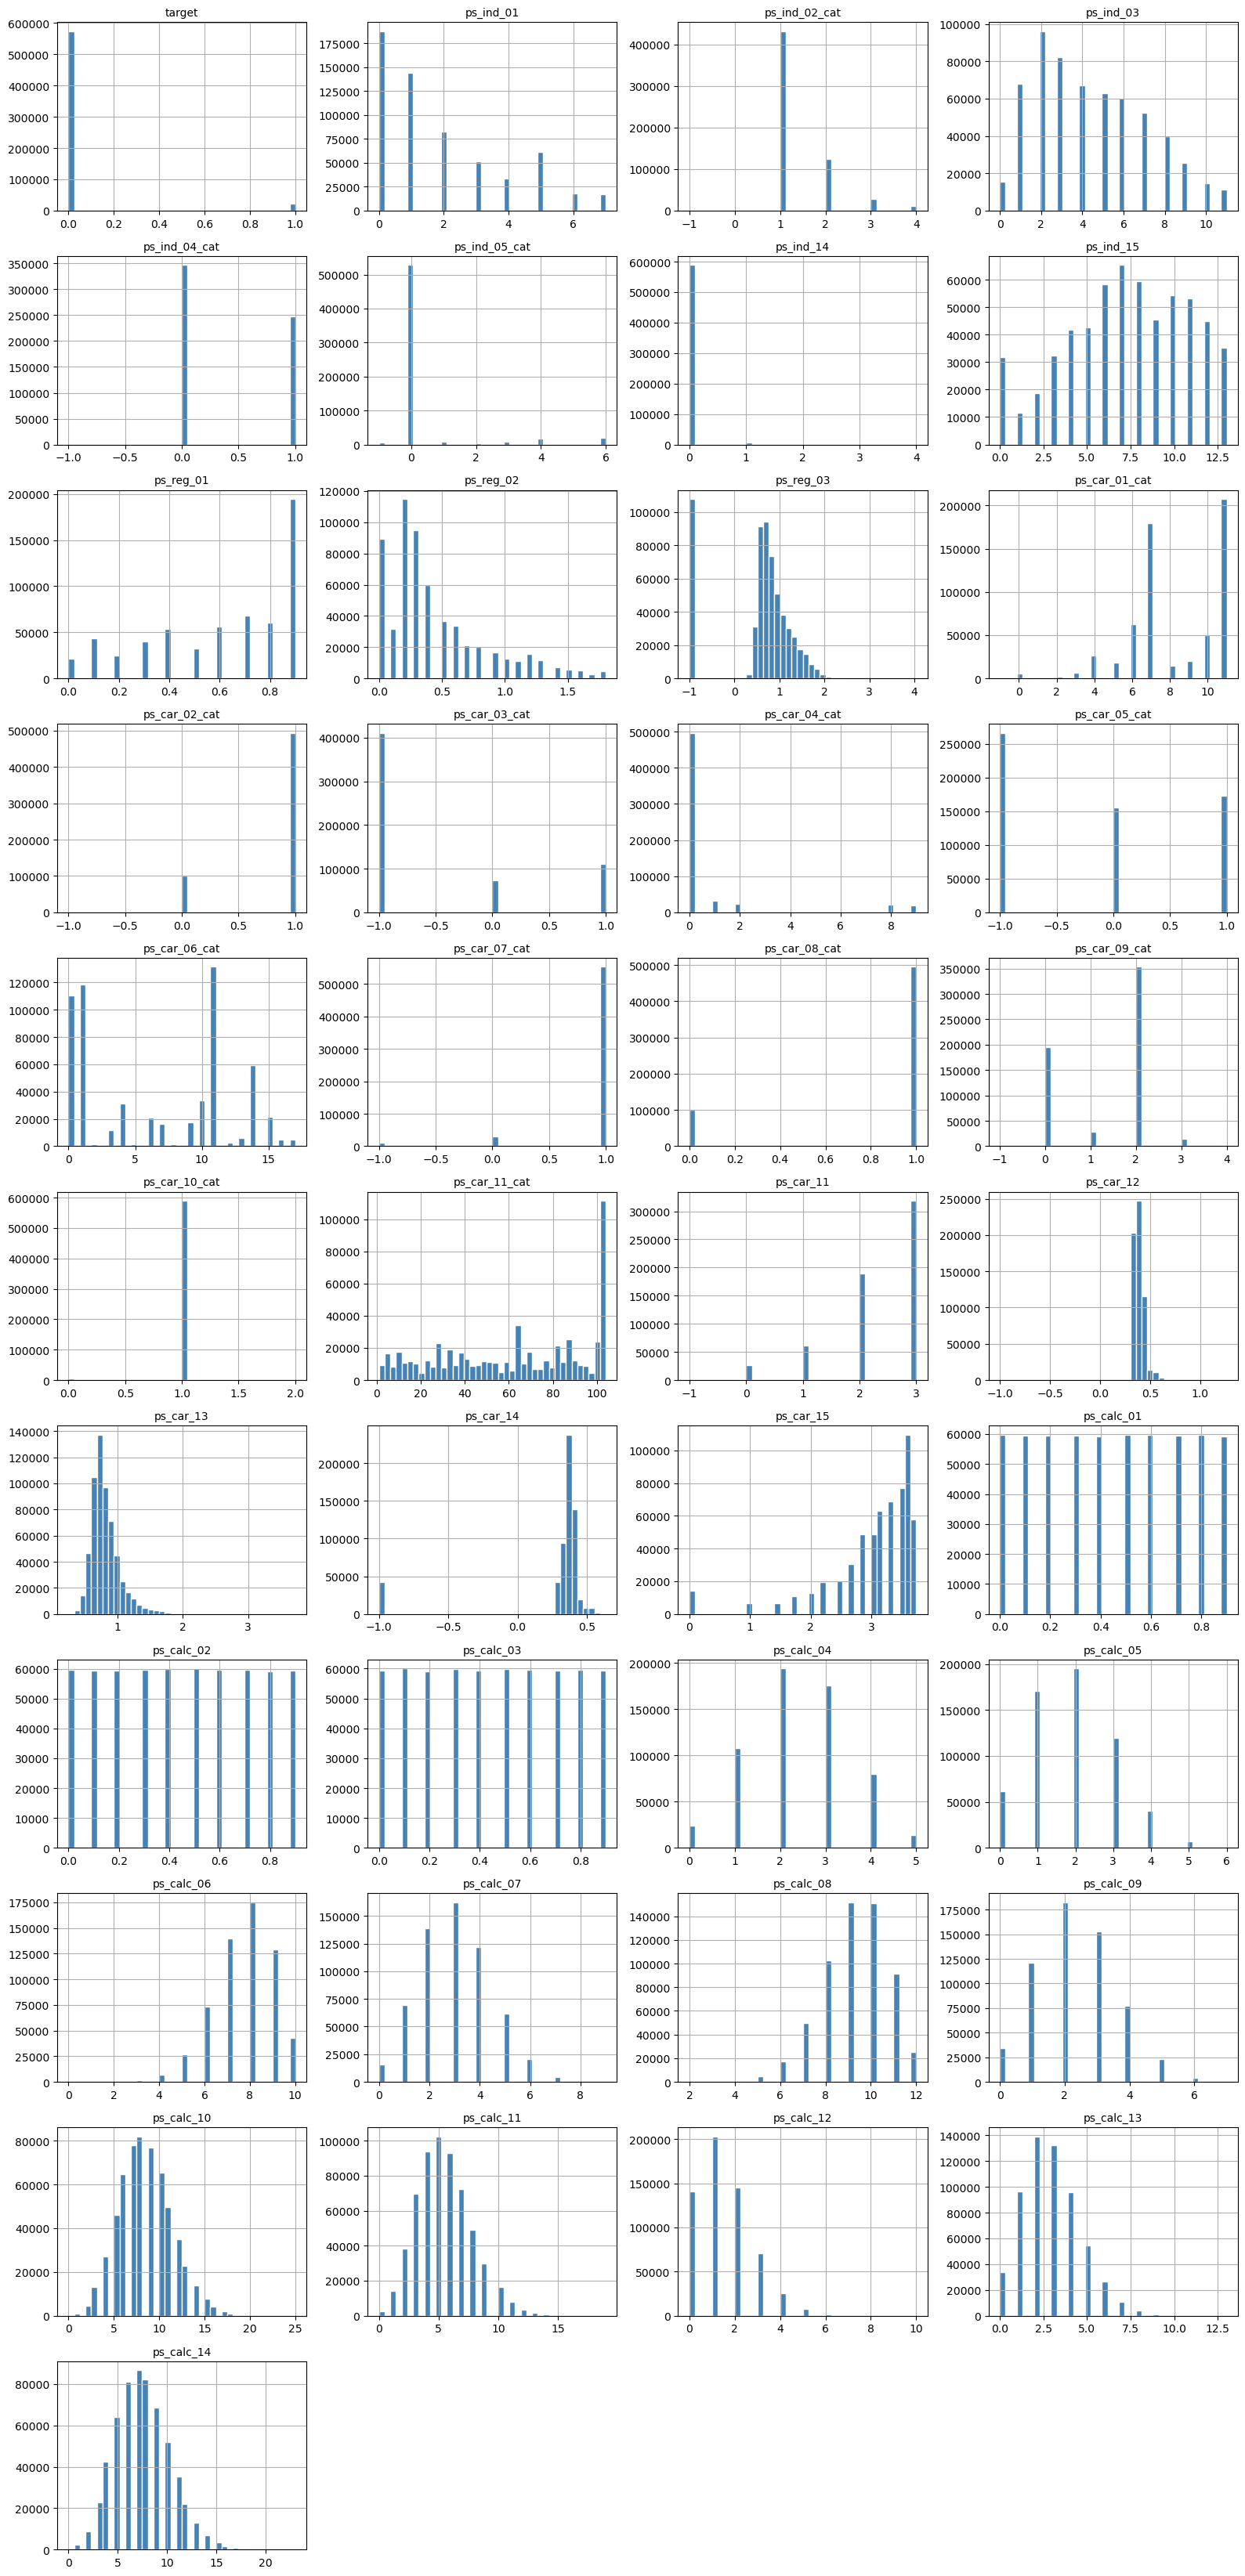

In [11]:
cols_to_keep = [col for col in train_data.columns if 'bin' not in col and col != 'id']
n_cols = len(cols_to_keep)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()
for i, col in enumerate(cols_to_keep):
    train_data[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(cols_to_keep), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [12]:
print(train_data['target'].value_counts(normalize=True))

target
0    0.963552
1    0.036448
Name: proportion, dtype: float64


In [13]:
corr_matrix = train_data.corr()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
strong_pairs = upper_tri.stack().reset_index()
strong_pairs.columns = ['Признак_1', 'Признак_2', 'Корреляция']
strong_pairs = strong_pairs[strong_pairs['Корреляция'] > 0.6]
strong_pairs = strong_pairs.sort_values('Корреляция', ascending=False)
print(strong_pairs)

          Признак_1  Признак_2  Корреляция
677   ps_ind_12_bin  ps_ind_14    0.890127
1435      ps_car_12  ps_car_13    0.671720
971       ps_reg_01  ps_reg_03    0.637035


Проведём обучение на тренирововчном датасете без future_engeneering, посмотрим на результаты тестирования, вдруг модель без тюнинга будет хорошо предсказывать target и иметь хорошие показатели по ROC-AUC и PR-кривой

In [16]:
y_cls = train_data['target']
X_cls = train_data.drop('target',axis=1)
X_train_cls,X_test_cls,y_train_cls,y_test_cls = train_test_split(X_cls,y_cls,test_size=0.2, random_state=42)
X_train_cls = X_train_cls.drop('id',axis = 1)
X_test_cls = X_test_cls.drop('id',axis = 1)
model = xgb.XGBClassifier(n_estimators=100,       
    learning_rate=0.1,      
    max_depth=5,            
    random_state=42,
    n_jobs=-1               
)
model.fit(X_train_cls, y_train_cls)
y_proba_cls = model.predict_proba(X_test_cls)[:, 1]
roc_auc = roc_auc_score(y_test_cls, y_proba_cls)
print(f"ROC-AUC: {roc_auc:.3f}")

ROC-AUC: 0.641


Как мы видим ROC-AUC равен 0.641, что чуть лучше чем модель выбирающая результат случайным образом, график PR-кривой соответсвует графику обратной пропорциональности

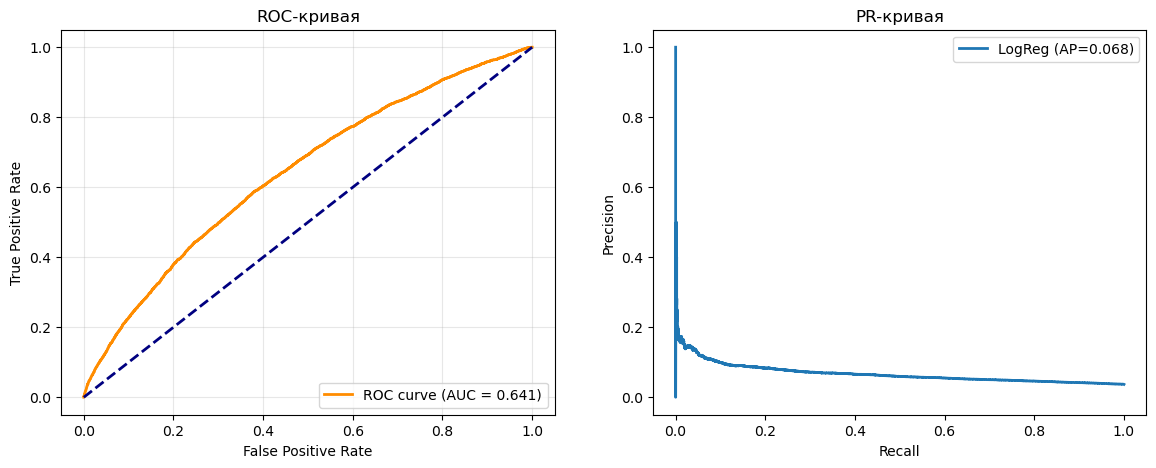

<Figure size 800x600 with 0 Axes>

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fpr, tpr, _ = roc_curve(y_test_cls, y_proba_cls)
plt.figure(figsize=(8, 6))
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC-кривая')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)


prec, rec, _ = precision_recall_curve(y_test_cls, y_proba_cls)
ap = average_precision_score(y_test_cls, y_proba_cls)
axes[1].plot(rec, prec, linewidth=2, label=f'LogReg (AP={ap:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR-кривая')
axes[1].legend()

plt.tight_layout()
plt.show()

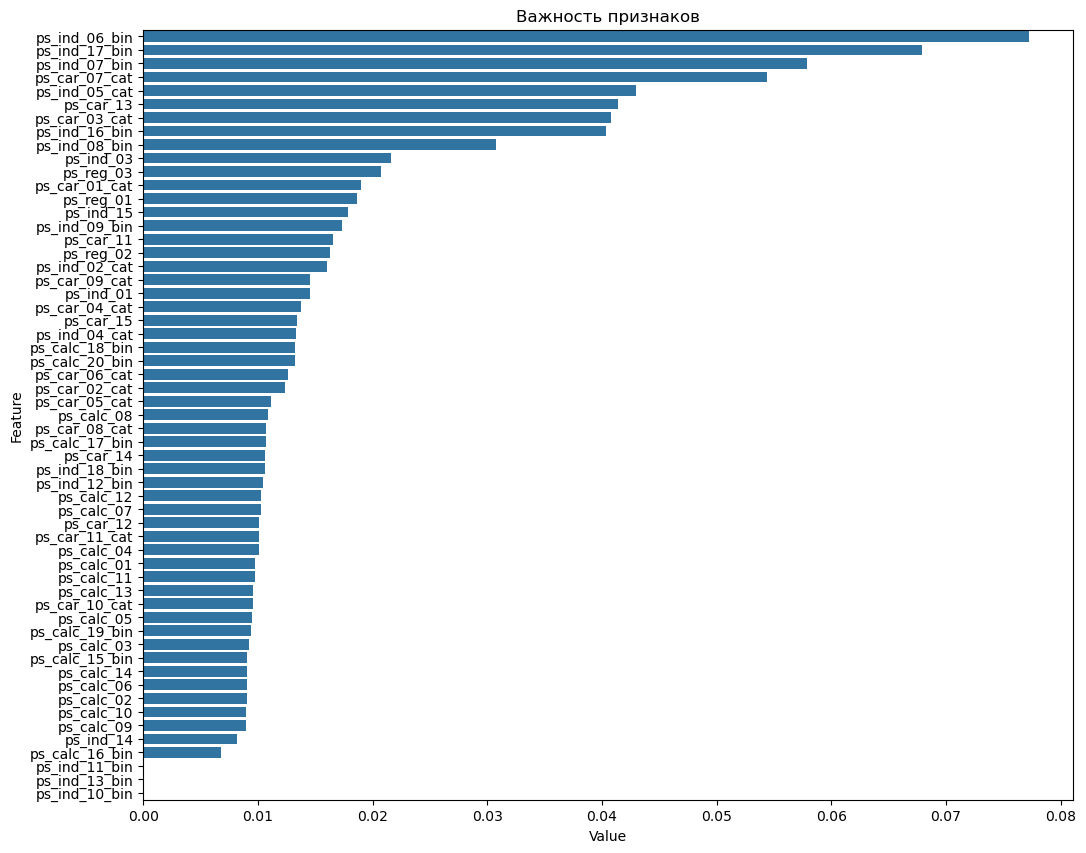

In [17]:
feature_imp = pd.DataFrame({
    'Value': model.feature_importances_,
    'Feature': X_train_cls.columns
})
feature_imp = feature_imp.sort_values(by="Value", ascending=False).reset_index(drop=True)
plt.figure(figsize=(12, 10))
sns.barplot(x="Value", y="Feature", data=feature_imp) 
plt.title('Важность признаков')
plt.show()

Проведём feature_engineering, переведём все -1 в np.nan, чтобы XGBoost и другие модели, умеющие работать с пропусками, понимали, что это пропуск  и статистика по признаку была подсчитана корректно, проведём на тренировачных и тестовых данных, чтобы не было утечки данных, добавим новый столбец missing, чтобы было подсчитано, сколько по каждому признаку было пропущено значений и удалим столбцы с названием calc, так как их вклад в предсказание модели минимален, также этот признак обозначает, что он создан комбинацией двух других признаков и добавляет в данные шума

In [18]:
drop_features = ['id','target']
y = train_data['target']
X = train_data.drop(columns = drop_features)
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X, y, test_size=0.2, random_state=42)
X_train_xgb['missing'] = (X_train_xgb == -1).sum(axis=1).astype(float)
X_test_xgb['missing'] = (X_test_xgb == -1).sum(axis=1).astype(float)
X_train_xgb = X_train_xgb.replace(-1, np.nan)
X_test_xgb = X_test_xgb.replace(-1, np.nan)
feature_names = X_train_xgb.columns.tolist() 
calc_names_1 = [i for i in feature_names if 'calc' in i]

In [19]:
X_train_xgb = X_train_xgb.drop(calc_names_1,axis=1)
X_test_xgb = X_test_xgb.drop(calc_names_1,axis=1)

In [20]:
X_test_xgb.head()

,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,...,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,missing
256886,4,1.0,5,1.0,0.0,1,0,0,0,0,...,1,0.0,1,16,3.0,0.421782,0.596720,0.373497,1.414214,1.0
118785,6,2.0,10,1.0,0.0,0,0,0,1,0,...,1,0.0,1,104,1.0,0.424264,1.237825,0.446094,3.162278,1.0
56083,4,1.0,9,1.0,0.0,0,0,1,0,0,...,1,1.0,1,31,3.0,0.400000,0.546628,NaN,1.000000,2.0
542002,0,1.0,7,1.0,4.0,0,1,0,0,0,...,0,2.0,1,97,3.0,0.360555,0.874147,0.298329,3.605551,0.0
349518,1,1.0,3,1.0,0.0,1,0,0,0,0,...,1,2.0,1,38,3.0,0.316228,0.740165,0.359861,3.464102,2.0


In [21]:
def Gini(y_true, y_pred):
    assert y_true.shape == y_pred.shape
    n_samples = y_true.shape[0]
    arr = np.array([y_true, y_pred]).transpose()
    true_order = arr[arr[:, 0].argsort()][::-1, 0]
    pred_order = arr[arr[:, 1].argsort()][::-1, 0]
    L_true = np.cumsum(true_order) * 1. / np.sum(true_order)
    L_pred = np.cumsum(pred_order) * 1. / np.sum(pred_order)
    L_ones = np.linspace(1 / n_samples, 1, n_samples)
    G_true = np.sum(L_ones - L_true)
    G_pred = np.sum(L_ones - L_pred)
    return G_pred * 1. / G_true
cv_only = True
save_cv = True
full_train = False
def evalerror(preds, dtrain):
    labels = dtrain.get_label()
    return 'gini', Gini(labels, preds), True

In [22]:
from sklearn.model_selection import KFold
from xgboost import XGBClassifier

Сравним три модели: XGBClassifier,LGBMClassifier и сделаем стекинг из моделей:LGBMClassifier,XGBClassifier и estimator_model = LogosticRegression

In [23]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'auc',
        'early_stopping_rounds': 30,
}
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    gini_scores = []
    for train_idx, val_idx in cv.split(X_train_xgb):
        X_tr, X_val = X_train_xgb.iloc[train_idx], X_train_xgb.iloc[val_idx]
        y_tr, y_val = y_train_xgb.iloc[train_idx], y_train_xgb.iloc[val_idx]
        model = XGBClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        preds = model.predict_proba(X_val)[:, 1]
        gini_scores.append(Gini(y_val.values, preds))
    return np.mean(gini_scores)

In [22]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10, show_progress_bar=True)
print('Лучшие параметры:', study.best_params)
print('Лучший Gini на CV (train):', study.best_value)

[I 2026-08-17 16:12:08,353] A new study created in memory with name: no-name-55bc6925-016e-4d14-943a-6e92946da231


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-08-17 16:13:40,675] Trial 0 finished with value: 0.2736286956372058 and parameters: {'n_estimators': 604, 'max_depth': 3, 'learning_rate': 0.3687061780122636}. Best is trial 0 with value: 0.2736286956372058.
[I 2026-08-17 16:20:34,286] Trial 1 finished with value: 0.2763773571553807 and parameters: {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.01774924842538309}. Best is trial 1 with value: 0.2763773571553807.
[I 2026-08-17 16:23:21,628] Trial 2 finished with value: 0.27306336233275474 and parameters: {'n_estimators': 132, 'max_depth': 7, 'learning_rate': 0.04208366572897327}. Best is trial 1 with value: 0.2763773571553807.
[I 2026-08-17 16:24:18,360] Trial 3 finished with value: 0.16033647119811228 and parameters: {'n_estimators': 373, 'max_depth': 10, 'learning_rate': 0.9702152011272571}. Best is trial 1 with value: 0.2763773571553807.
[I 2026-08-17 16:25:07,819] Trial 4 finished with value: 0.2376729843610633 and parameters: {'n_estimators': 751, 'max_depth': 5, '

NameError: name 'best_params' is not defined

In [24]:
best_params_xgb = {'n_estimators': 645, 'max_depth': 3, 'learning_rate': 0.07617414131646684}
n_estimators_xgb = 645

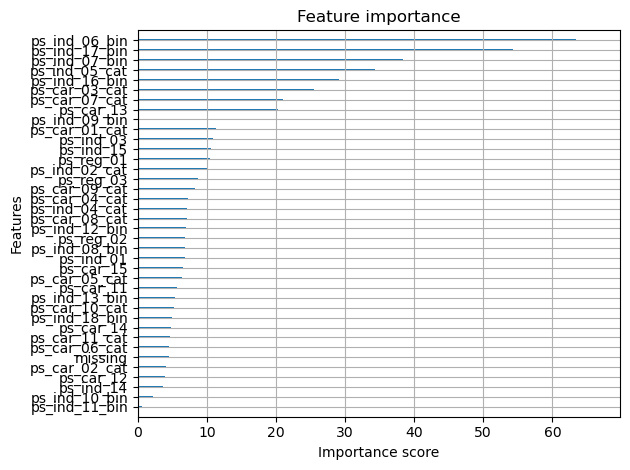

In [27]:
best_model = xgb.XGBClassifier(
    **best_params_xgb,
    random_state=42,
    eval_metric='logloss'
)
best_model.fit(X_train_xgb, y_train_xgb)
ax = plot_importance(
    best_model, 
    importance_type='gain',
    show_values=False 
)
plt.tight_layout()
plt.show()

Как мы видим важность признаков также сохранилась и после future_engineering, признаки с calc не влияли на предсказания

In [33]:
pip install lightGBM

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 2.6 MB/s eta 0:00:01
   ------------------------------ --------- 1.0/1.4 MB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 2.1 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [28]:
from lightgbm import LGBMClassifier
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 255, step=2),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100, step=5),
        'random_state': 42,
        'n_jobs': -1,
    }
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    gini_scores = []
    for train_idx, val_idx in cv.split(X_train_xgb):
        X_tr, X_val = X_train_xgb.iloc[train_idx], X_train_xgb.iloc[val_idx]
        y_tr, y_val = y_train_xgb.iloc[train_idx], y_train_xgb.iloc[val_idx]
        model = LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
        )
        preds = model.predict_proba(X_val)[:, 1]
        gini_scores.append(Gini(y_val.values, preds))
    return np.mean(gini_scores)

In [41]:
study = optuna.create_study(direction='maximize')
study.optimize(objective_lgbm, n_trials=10, show_progress_bar=True)
print('Лучшие параметры:', study.best_params)
print('Лучший Gini на CV (train):', study.best_value)
best_params_lgbm = {'n_estimators': 650, 'learning_rate': 0.02357597375489924, 'num_leaves': 33, 'max_depth': 4, 'min_child_samples': 50}
n_estimators_lgbm = best_params_lgbm.pop('n_estimators')

[I 2026-08-17 22:31:01,799] A new study created in memory with name: no-name-b41963c9-4be1-4770-8718-5314ccfcf675


  0%|          | 0/10 [00:00<?, ?it/s]

C:\Users\andre\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 13850, number of negative: 367085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.036900 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1187
[LightGBM] [Info] Number of data points in the train set: 380935, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036358 -> initscore=-3.277308
[LightGBM] [Info] Start training from score -3.277308


C:\Users\andre\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


...

C:\Users\andre\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 13832, number of negative: 367103
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.056216 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1187
[LightGBM] [Info] Number of data points in the train set: 380935, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036311 -> initscore=-3.278658
[LightGBM] [Info] Start training from score -3.278658


C:\Users\andre\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 13875, number of negative: 367061
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.064560 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1189
[LightGBM] [Info] Number of data points in the train set: 380936, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036423 -> initscore=-3.275439
[LightGBM] [Info] Start training from score -3.275439
[I 2026-08-17 23:09:52,480] Trial 9 finished with value: 0.14096901412920262 and parameters: {'n_estimators': 650, 'learning_rate': 0.10510151256300448, 'num_leaves': 189, 'max_depth': 10, 'min_child_samples': 5}. Best is trial 6 with value: 0.2779660403783998.
Лучшие параметры: {'n_estimators': 650, 'learning_rate': 0.02357597375489924, 'num_leaves': 33, 'max_depth': 4, 'min_child_samples': 50}
Лучший Gini на CV (train): 0.277966040378

NameError: name 'best_params_flgbm' is not defined

Лучшие параметры: {'n_estimators': 650, 'learning_rate': 0.02357597375489924, 'num_leaves': 33, 'max_depth': 4, 'min_child_samples': 50}
Лучший Gini на CV (train): 0.2779660403783998

In [29]:
best_params_lgbm = {'n_estimators': 650, 'learning_rate': 0.02357597375489924, 'num_leaves': 33, 'max_depth': 4, 'min_child_samples': 50}
n_estimators_lgbm = best_params_lgbm.pop('n_estimators')

In [33]:
feature_list = [f'feature_{i}' for i in range(X_train_xgb.shape[1])]
best_model_lgbm = LGBMClassifier(
    n_estimators=n_estimators_lgbm,
    **best_params_lgbm,
    random_state=42,
    feature_name=feature_list # Передаем имена явно
)
best_model_lgbm.fit(X_train_xgb, y_train_xgb)
importance_df = pd.DataFrame({
    'feature': best_model_lgbm.feature_name_,
    'importance': best_model_lgbm.feature_importances_
}).sort_values('importance', ascending=False)
print(importance_df)

C:\Users\andre\anaconda3\Lib\site-packages\lightgbm\basic.py:2120: UserWarning: feature_name keyword has been found in `params` and will be ignored.
Please use feature_name argument of the Dataset constructor to pass this parameter.
  _log_warning(


[LightGBM] [Warning] Unknown parameter: feature_name
[LightGBM] [Warning] Unknown parameter: feature_name
[LightGBM] [Info] Number of positive: 17309, number of negative: 458860
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.068504 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1188
[LightGBM] [Info] Number of data points in the train set: 476169, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036351 -> initscore=-3.277519
[LightGBM] [Info] Start training from score -3.277519
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

In [90]:
importance_df.head(10)

,feature,importance
20,ps_reg_03,1255
34,ps_car_13,804
2,ps_ind_03,789
35,ps_car_14,744
0,ps_ind_01,481
14,ps_ind_15,473
31,ps_car_11_cat,388
18,ps_reg_01,378
33,ps_car_12,372
19,ps_reg_02,348


Как мы видим из первых десяти признаков есть только одна категориальная и нет ни одной бинарной переменной, есть только числовые признаки

Сделаем стекинг из нескольких моделей, предсказания будут делать RandomForestClassifier и XGBoostclassifier со своими лучшими параметрами, предсказывать мета-признаки будет мета-модель - LogisticRegression

In [45]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
kf = KFold(n_splits=5, shuffle=True, random_state=42)
gini_scores = []
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_xgb)):
    print(f"Обучение фолда {fold + 1}/5")
    X_tr, X_val = X_train_xgb.iloc[train_idx], X_train_xgb.iloc[val_idx]
    y_tr, y_val = y_train_xgb.iloc[train_idx], y_train_xgb.iloc[val_idx]
    stacking = StackingClassifier(
        estimators=[
            ('xgb', XGBClassifier(**best_params_xgb)),
            ('LGBM', LGBMClassifier(**best_params_lgbm, random_state=42, n_jobs=-1)),
        ],
        final_estimator=LogisticRegression(random_state=42, max_iter=500),
        cv=5, 
        n_jobs=-1, 
        stack_method = 'predict_proba',
        passthrough = False
    )
    stacking.fit(X_tr, y_tr)
    y_proba_stack = stacking.predict_proba(X_val)[:, 1]
    gini_score = Gini(y_val.values, y_proba_stack)
    gini_scores.append(gini_score)
    print(f"Gini на фолде {fold + 1}: {gini_score:.4f}")
print(f'\nСредний Gini по CV: {np.mean(gini_scores):.4f} +/- {np.std(gini_scores):.4f}')

Обучение фолда 1/5
Gini на фолде 1: 0.2805
Обучение фолда 2/5
Gini на фолде 2: 0.2731
Обучение фолда 3/5
Gini на фолде 3: 0.2801
Обучение фолда 4/5
Gini на фолде 4: 0.2906
Обучение фолда 5/5
Gini на фолде 5: 0.2711

Средний Gini по CV: 0.2791 +/- 0.0069


Как мы видим стекинг показал лучше результат чем LGBMClassifier(средний Gini = 0.2791 vs 2778), но немного хуже чем XGBClassifier(средний Gini = 0.2791 vs 0.28)по среднему Gini, но при этом стекинг имеет очень низкий variance, что говорит об устойчивости модели

Проведём дополнительный future_engeeniring, сгруппируем данные по категориальным, оставим только числовые и бинарные данные и обучим на этих признаках XGBoostClassifier и LightGBM со совими лучшими гиперпараметрами по Optuna, сделаем frequency_encoding по категориальным признакам и оставим только числовые и бинарные, посмотрим как изменится результат по метрике соревнований

In [70]:
import numpy as np
from sklearn.model_selection import train_test_split
X_train_feat, X_test_feat, y_train_feat, y_test_feat = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
features_names = X_train_feat.columns.tolist()
calc_names = [i for i in features_names if 'calc' in i]
cat_features = [i for i in features_names if 'cat' in i and 'calc' not in i]
if calc_names: 
    X_train_feat = X_train_feat.drop(calc_names, axis=1)
    X_test_feat = X_test_feat.drop(calc_names, axis=1)
X_train_feat['missing'] = (X_train_feat == -1).sum(axis=1).astype(float)
X_test_feat['missing'] = (X_test_feat == -1).sum(axis=1).astype(float)
X_train_feat = X_train_feat.replace(-1, np.nan)
X_test_feat = X_test_feat.replace(-1, np.nan)
for col in cat_features:
    freq_map = X_train_feat[col].value_counts(dropna=False).to_dict()
    X_train_feat[f'{col}_freq'] = X_train_feat[col].map(freq_map)
    X_test_feat[f'{col}_freq'] = X_test_feat[col].map(freq_map).fillna(0)
    X_train_feat = X_train_feat.drop(col, axis=1)
    X_test_feat = X_test_feat.drop(col, axis=1)  

In [74]:
X_train_feat['missing']

520363    1.0
271468    2.0
575806    1.0
145105    1.0
31107     2.0
         ... 
72635     3.0
129319    1.0
90875     2.0
417177    1.0
439357    2.0
Name: missing, Length: 476169, dtype: float64

In [76]:
params_best = {
    'n_estimators': 645,
    'max_depth': 3,
    'learning_rate': 0.076174141316466844,
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': 'hist',
}
cv = KFold(n_splits=5, shuffle=True, random_state=42)
gini_scores = []
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_feat), 1):
    X_tr, X_val = X_train_feat.iloc[train_idx], X_train_feat.iloc[val_idx]
    y_tr, y_val = y_train_feat.iloc[train_idx], y_train_feat.iloc[val_idx]
    model = XGBClassifier(**params_best)
    model.fit(
        X_tr, y_tr,
        verbose=False
    )
    preds = model.predict_proba(X_val)[:, 1]
    score = Gini(y_val.values, preds)
    gini_scores.append(score)
    print(f"Fold {fold}: Gini = {score:.6f}")
mean_score = np.mean(gini_scores)

Fold 1: Gini = 0.264135
Fold 2: Gini = 0.280648
Fold 3: Gini = 0.283325
Fold 4: Gini = 0.270358
Fold 5: Gini = 0.287008


In [77]:
print(f'{np.mean(gini_scores):.4f} +/- {np.std(gini_scores):.4f}')

0.2771 +/- 0.0085


In [78]:
params_lgbm = {
    'n_estimators': 650,
    'learning_rate': 0.02357597375489924,
    'num_leaves': 33,
    'max_depth': 4,
    'min_child_samples': 50,
    'random_state': 42,
    'n_jobs': -1,
}
cv = KFold(n_splits=5, shuffle=True, random_state=42)
gini_scores = []
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_feat), 1):
    X_tr, X_val = X_train_feat.iloc[train_idx], X_train_feat.iloc[val_idx]
    y_tr, y_val = y_train_feat.iloc[train_idx], y_train_feat.iloc[val_idx]
    model = LGBMClassifier(**params_lgbm)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)]
        )
    preds = model.predict_proba(X_val)[:, 1]
    gini_scores.append(Gini(y_val.values, preds))
    print(f"Fold {fold}: Gini = {score:.6f}")
mean_score = np.mean(gini_scores)
print(mean_score)
print(gini_scores)

C:\Users\andre\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 13888, number of negative: 367047
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040614 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1200
[LightGBM] [Info] Number of data points in the train set: 380935, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036458 -> initscore=-3.274465
[LightGBM] [Info] Start training from score -3.274465
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

C:\Users\andre\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 13928, number of negative: 367007
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.054373 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1197
[LightGBM] [Info] Number of data points in the train set: 380935, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036563 -> initscore=-3.271480
[LightGBM] [Info] Start training from score -3.271480
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

C:\Users\andre\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 13853, number of negative: 367082
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.057671 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1200
[LightGBM] [Info] Number of data points in the train set: 380935, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036366 -> initscore=-3.277083
[LightGBM] [Info] Start training from score -3.277083
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

C:\Users\andre\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 13904, number of negative: 367031
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.066329 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1201
[LightGBM] [Info] Number of data points in the train set: 380935, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036500 -> initscore=-3.273270
[LightGBM] [Info] Start training from score -3.273270
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

C:\Users\andre\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 13847, number of negative: 367089
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.063699 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1202
[LightGBM] [Info] Number of data points in the train set: 380936, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036350 -> initscore=-3.277536
[LightGBM] [Info] Start training from score -3.277536
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [79]:
print(f'{np.mean(gini_scores):.4f} +/- {np.std(gini_scores):.4f}')

0.2791 +/- 0.0093


Получилось лучше чем у XGBClassifier, но хуже чем у XGBoostclassifier до future_engeeniring

Попробуем последнюю модель стекинг из моделей и предсказание LogisticRegression по X_train_feat

In [80]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
gini_scores = []
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_feat)):
    print(f"Обучение фолда {fold + 1}/5")
    X_tr, X_val = X_train_feat.iloc[train_idx], X_train_feat.iloc[val_idx]
    y_tr, y_val = y_train_feat.iloc[train_idx], y_train_feat.iloc[val_idx]
    stacking = StackingClassifier(
        estimators=[
            ('xgb', XGBClassifier(**best_params_xgb)),
            ('LGBM', LGBMClassifier(**best_params_lgbm, random_state=42, n_jobs=-1)),
        ],
        final_estimator=LogisticRegression(random_state=42, max_iter=500),
        cv=5, 
        n_jobs=-1, 
        stack_method = 'predict_proba',
        passthrough = False
    )
    stacking.fit(X_tr, y_tr)
    y_proba_stack = stacking.predict_proba(X_val)[:, 1]
    gini_score = Gini(y_val.values, y_proba_stack)
    gini_scores.append(gini_score)
    print(f"Gini на фолде {fold + 1}: {gini_score:.4f}")
print(f'\nСредний Gini по CV: {np.mean(gini_scores):.4f} +/- {np.std(gini_scores):.4f}')

Обучение фолда 1/5
Gini на фолде 1: 0.2657
Обучение фолда 2/5
Gini на фолде 2: 0.2820
Обучение фолда 3/5
Gini на фолде 3: 0.2848
Обучение фолда 4/5
Gini на фолде 4: 0.2690
Обучение фолда 5/5
Gini на фолде 5: 0.2899

Средний Gini по CV: 0.2783 +/- 0.0093


Gini (CV): до FE — XGB: 0.2801, LGB: 0.2780, Stacking: 0.2791; после FE — XGB: 0.2771, LGB: 0.2791, Stacking: 0.2783

Выводы: Метрика ансамблевой модели изменилась незначительно (с 0.2791 до 0.2783), XGBoost потерял в качестве сильнее остальных, снизив Gini с 0.2801 до 0.2771 (-0.0030), LightGBM показал рост метрики с 0.2780 до 0.2791 (+0.0011)

Для финального предсказания используем XGBClassifier с параметрами на optuna

In [86]:
drop_features = ['id','target']
y_final = train_data['target']
test_ids = test_data['id'].copy()
X_final = train_data.drop(columns = drop_features)
feature_names = X_train_xgb.columns.tolist() 
calc_names_1 = [i for i in feature_names if 'calc' in i]
X_final = X_final.drop(columns = calc_names_1)
X_test_final = test_data.drop(columns = calc_names_1)
X_test_final = test_data.drop(columns=['id'] + calc_names_1)
X_final['missing'] = (X_final == -1).sum(axis=1).astype(float)
X_test_final['missing'] = (X_test_final == -1).sum(axis=1).astype(float)
X_final = X_final.replace(-1, np.nan)
X_test_final = X_test_final.replace(-1, np.nan)
final_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'tree_method': 'hist', 
    'n_estimators': 645,    
    'learning_rate': 0.076174141316466844,
    'max_depth': 3,    
    'n_jobs': -1,
    'random_state': 42
}
FOLDS = 5
kf = KFold(n_splits=FOLDS, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X_final))     
sub_preds = np.zeros(len(X_test_final)) 
for fold, (train_idx, val_idx) in enumerate(kf.split(X_final, y_final)):
    print(f"\n Training Fold {fold + 1} / {FOLDS}...")  
    X_tr, X_val = X_final.iloc[train_idx], X_final.iloc[val_idx]
    y_tr, y_val = y_final.iloc[train_idx], y_final.iloc[val_idx]    
    model = xgb.XGBClassifier(**final_params)   
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)], 
        verbose=False,
    )    
    val_preds = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_preds   
    fold_auc = roc_auc_score(y_val, val_preds)
    fold_gini = 2 * fold_auc - 1
    print(f"Fold {fold + 1} текущий AUC: {fold_auc:.5f} | Gini: {fold_gini:.5f}")   
    sub_preds += model.predict_proba(X_test_final)[:, 1] / FOLDS
print("-" * 40)
total_auc = roc_auc_score(y_final, oof_preds)
total_gini = 2 * total_auc - 1
submission = pd.DataFrame({
    'id': test_ids,
    'target': sub_preds
})
submission.to_csv('submission.csv', index=False)


 Training Fold 1 / 5...
Fold 1 текущий AUC: 0.63782 | Gini: 0.27563

 Training Fold 2 / 5...
Fold 2 текущий AUC: 0.63556 | Gini: 0.27113

 Training Fold 3 / 5...
Fold 3 текущий AUC: 0.64668 | Gini: 0.29337

 Training Fold 4 / 5...
Fold 4 текущий AUC: 0.63875 | Gini: 0.27750

 Training Fold 5 / 5...
Fold 5 текущий AUC: 0.63577 | Gini: 0.27154
----------------------------------------
